# Solar Cycle Peak Forecasting — Phase 3: Peak Magnitude Prediction

**Goal:** Predict `Peak_Sunspot_Number` from early-cycle observations only.

**Windows:** 12 months · 24 months · 36 months into the cycle  
**Models:** Linear Regression · Random Forest · XGBoost  
**Validation:** Leave-One-Cycle-Out (LOCO) Cross Validation — the only valid strategy with 24 samples


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    print("XGBoost not installed — skipping")
    HAS_XGB = False

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

RANDOM_STATE = 42
print(f"Imports OK | XGBoost: {HAS_XGB}")


Imports OK | XGBoost: True


## Load Data

In [4]:
comp = pd.read_csv("../data/Cycle_Database_completed.csv", parse_dates=["Start_Date","End_Date","Peak_Date"])
comp = comp.sort_values("Cycle_ID").reset_index(drop=True)

print(f"Completed cycles: {len(comp)}  (SC1 – SC{int(comp['Cycle_ID'].max())})")
print(f"Columns: {comp.shape[1]}")
comp[["Cycle_ID","Peak_Sunspot_Number","w12_mean","w24_mean","w36_mean"]].head()


Completed cycles: 24  (SC1 – SC24)
Columns: 58


,Cycle_ID,Peak_Sunspot_Number,w12_mean,w24_mean,w36_mean
0,1,144.1,16.250000,16.729167,30.255556
1,2,193.0,28.841667,54.504167,79.141667
2,3,264.2,17.450000,40.775000,102.102778
3,4,235.3,26.583333,61.104167,105.875000
4,5,82.0,9.208333,9.837500,17.186111


## Feature Sets per Window

In [5]:
# Define feature sets for each window
def get_features(w):
    candidates = [
        f"w{w}_mean", f"w{w}_max", f"w{w}_slope", f"w{w}_growth_rate",
        f"w{w}_std", f"w{w}_last",
        f"w{w}_rolling_mean_3", f"w{w}_rolling_mean_6",
        f"w{w}_lag1", f"w{w}_lag3",
        f"w{w}_frac_above_median",
    ]
    # Add 12m features into 24/36m windows (they already observed them)
    if w >= 24:
        candidates += ["w12_mean","w12_max","w12_slope","w12_growth_rate"]
    if w >= 36:
        candidates += ["w24_mean","w24_max","w24_slope"]
    # Keep only columns that exist and have no NaN in completed cycles
    available = [c for c in candidates if c in comp.columns and comp[c].notna().all()]
    return available

for w in [12, 24, 36]:
    feats = get_features(w)
    print(f"w{w}: {len(feats)} features — {feats}")

w12: 11 features — ['w12_mean', 'w12_max', 'w12_slope', 'w12_growth_rate', 'w12_std', 'w12_last', 'w12_rolling_mean_3', 'w12_rolling_mean_6', 'w12_lag1', 'w12_lag3', 'w12_frac_above_median']
w24: 15 features — ['w24_mean', 'w24_max', 'w24_slope', 'w24_growth_rate', 'w24_std', 'w24_last', 'w24_rolling_mean_3', 'w24_rolling_mean_6', 'w24_lag1', 'w24_lag3', 'w24_frac_above_median', 'w12_mean', 'w12_max', 'w12_slope', 'w12_growth_rate']
w36: 18 features — ['w36_mean', 'w36_max', 'w36_slope', 'w36_growth_rate', 'w36_std', 'w36_last', 'w36_rolling_mean_3', 'w36_rolling_mean_6', 'w36_lag1', 'w36_lag3', 'w36_frac_above_median', 'w12_mean', 'w12_max', 'w12_slope', 'w12_growth_rate', 'w24_mean', 'w24_max', 'w24_slope']


## LOCO Cross-Validation

In [6]:
TARGET = "Peak_Sunspot_Number"

def loco_cv(df, feature_cols, target_col, model_fn):
    """
    Leave-One-Cycle-Out CV.
    Winsorization of growth_rate using fixed physical bounds per fold.
    Scaling fit on training fold only.
    """
    growth_indices = [i for i, c in enumerate(feature_cols) if "growth_rate" in c]

    records = []
    for i in df.index:
        train_idx = [j for j in df.index if j != i]
        X_train = df.loc[train_idx, feature_cols].values.copy()
        y_train = df.loc[train_idx, target_col].values
        X_test  = df.loc[[i], feature_cols].values.copy()
        y_test  = df.loc[i, target_col]

        # Winsorize growth_rate with fixed physical bounds (no data leakage)
        for idx in growth_indices:
            X_train[:, idx] = np.clip(X_train[:, idx], -5, 50)
            X_test[:, idx]  = np.clip(X_test[:, idx],  -5, 50)

        # Scale using training fold only
        scaler = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        model = model_fn()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)[0]

        records.append({
            "Cycle_ID" : int(df.loc[i, "Cycle_ID"]),
            "y_true"   : y_test,
            "y_pred"   : y_pred,
            "error"    : y_pred - y_test,
            "abs_error": abs(y_pred - y_test),
        })
    return pd.DataFrame(records)


def summarise(loco_df, label):
    mae  = mean_absolute_error(loco_df["y_true"], loco_df["y_pred"])
    rmse = np.sqrt(mean_squared_error(loco_df["y_true"], loco_df["y_pred"]))
    return {"Model": label, "MAE": round(mae,2), "RMSE": round(rmse,2)}


print("LOCO CV function ready (fold-local winsorization, physical bounds).")

LOCO CV function ready (fold-local winsorization, physical bounds).


In [7]:
# ── Run LOCO CV for all windows × all models ──────────────────────────────────
models = {
    "Ridge"        : lambda: Ridge(alpha=10.0),
    "RandomForest" : lambda: RandomForestRegressor(n_estimators=300, max_depth=4,
                                                    min_samples_leaf=2, random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = lambda: XGBRegressor(n_estimators=200, max_depth=3,
                                              learning_rate=0.05, subsample=0.8,
                                              colsample_bytree=0.8, random_state=RANDOM_STATE,
                                              verbosity=0)

all_results    = []
all_loco_preds = {}

for w in [12, 24, 36]:
    feats = get_features(w)
    for mname, mfn in models.items():
        label = f"w{w}_{mname}"
        loco_df = loco_cv(comp, feats, TARGET, mfn)
        all_loco_preds[(w, mname)] = loco_df
        row = summarise(loco_df, label)
        all_results.append(row)
        print(f"  {label:<25s}  MAE={row['MAE']:6.2f}  RMSE={row['RMSE']:6.2f}")

results_df = pd.DataFrame(all_results).sort_values("RMSE")
print()
print(results_df.to_string(index=False))

  w12_Ridge                  MAE= 43.90  RMSE= 54.34
  w12_RandomForest           MAE= 50.35  RMSE= 57.35
  w12_XGBoost                MAE= 54.24  RMSE= 63.80
  w24_Ridge                  MAE= 32.17  RMSE= 37.50
  w24_RandomForest           MAE= 37.39  RMSE= 43.53
  w24_XGBoost                MAE= 42.15  RMSE= 46.91
  w36_Ridge                  MAE= 26.77  RMSE= 30.70
  w36_RandomForest           MAE= 32.07  RMSE= 36.66
  w36_XGBoost                MAE= 34.18  RMSE= 40.32

           Model   MAE  RMSE
       w36_Ridge 26.77 30.70
w36_RandomForest 32.07 36.66
       w24_Ridge 32.17 37.50
     w36_XGBoost 34.18 40.32
w24_RandomForest 37.39 43.53
     w24_XGBoost 42.15 46.91
       w12_Ridge 43.90 54.34
w12_RandomForest 50.35 57.35
     w12_XGBoost 54.24 63.80


## Results

In [8]:
print("=" * 55)
print("  PHASE 3 — LOCO CV RESULTS (sorted by RMSE)")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)
results_df


  PHASE 3 — LOCO CV RESULTS (sorted by RMSE)
           Model   MAE  RMSE
       w36_Ridge 26.77 30.70
w36_RandomForest 32.07 36.66
       w24_Ridge 32.17 37.50
     w36_XGBoost 34.18 40.32
w24_RandomForest 37.39 43.53
     w24_XGBoost 42.15 46.91
       w12_Ridge 43.90 54.34
w12_RandomForest 50.35 57.35
     w12_XGBoost 54.24 63.80


,Model,MAE,RMSE
6,w36_Ridge,26.77,30.70
7,w36_RandomForest,32.07,36.66
3,w24_Ridge,32.17,37.50
8,w36_XGBoost,34.18,40.32
4,w24_RandomForest,37.39,43.53
5,w24_XGBoost,42.15,46.91
0,w12_Ridge,43.90,54.34
1,w12_RandomForest,50.35,57.35
2,w12_XGBoost,54.24,63.80


In [9]:
# ── Per-cycle prediction errors for best model per window ────────────────────
# Find best model (lowest RMSE) for each window
best_per_window = {}
for w in [12, 24, 36]:
    w_results = results_df[results_df["Model"].str.startswith(f"w{w}_")]
    best_name  = w_results.sort_values("RMSE").iloc[0]["Model"]
    best_mname = best_name.replace(f"w{w}_","")
    best_per_window[w] = best_mname
    print(f"Best model at w{w}: {best_mname}")


Best model at w12: Ridge
Best model at w24: Ridge
Best model at w36: Ridge


## Visualisations

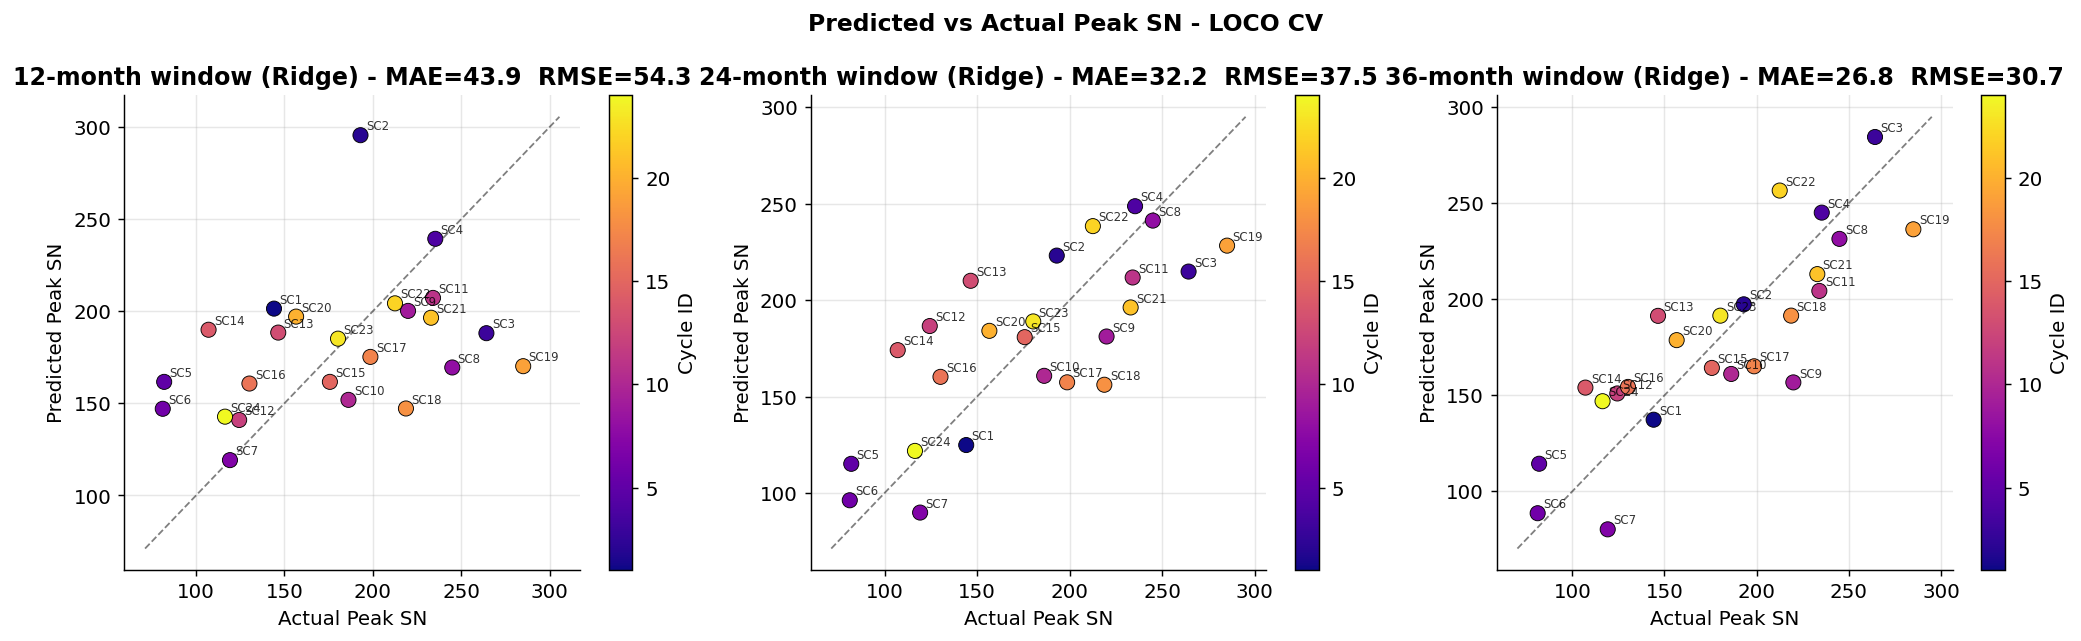

Saved: plots/phase3_pred_vs_actual.png


In [10]:
# ── Plot 1: Predicted vs Actual for best model at each window ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, w in zip(axes, [12, 24, 36]):
    mname  = best_per_window[w]
    loco   = all_loco_preds[(w, mname)]
    mae    = mean_absolute_error(loco["y_true"], loco["y_pred"])
    rmse   = np.sqrt(mean_squared_error(loco["y_true"], loco["y_pred"]))

    lo = min(loco["y_true"].min(), loco["y_pred"].min()) - 10
    hi = max(loco["y_true"].max(), loco["y_pred"].max()) + 10
    ax.plot([lo,hi],[lo,hi],"k--",lw=1,alpha=0.5,label="Perfect")
    sc = ax.scatter(loco["y_true"], loco["y_pred"],
                    c=loco["Cycle_ID"], cmap="plasma", s=70,
                    edgecolors="k", linewidths=0.5, zorder=3)
    for _, row in loco.iterrows():
        ax.annotate(f"SC{int(row['Cycle_ID'])}", (row["y_true"], row["y_pred"]),
                    fontsize=6.5, xytext=(3,3), textcoords="offset points", alpha=0.8)

    ax.set_xlabel("Actual Peak SN")
    ax.set_ylabel("Predicted Peak SN")
    ax.set_title(f"{w}-month window ({mname}) - MAE={mae:.1f}  RMSE={rmse:.1f}", fontweight="bold")
    plt.colorbar(sc, ax=ax, label="Cycle ID")

plt.suptitle("Predicted vs Actual Peak SN - LOCO CV", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/phase3_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/phase3_pred_vs_actual.png")

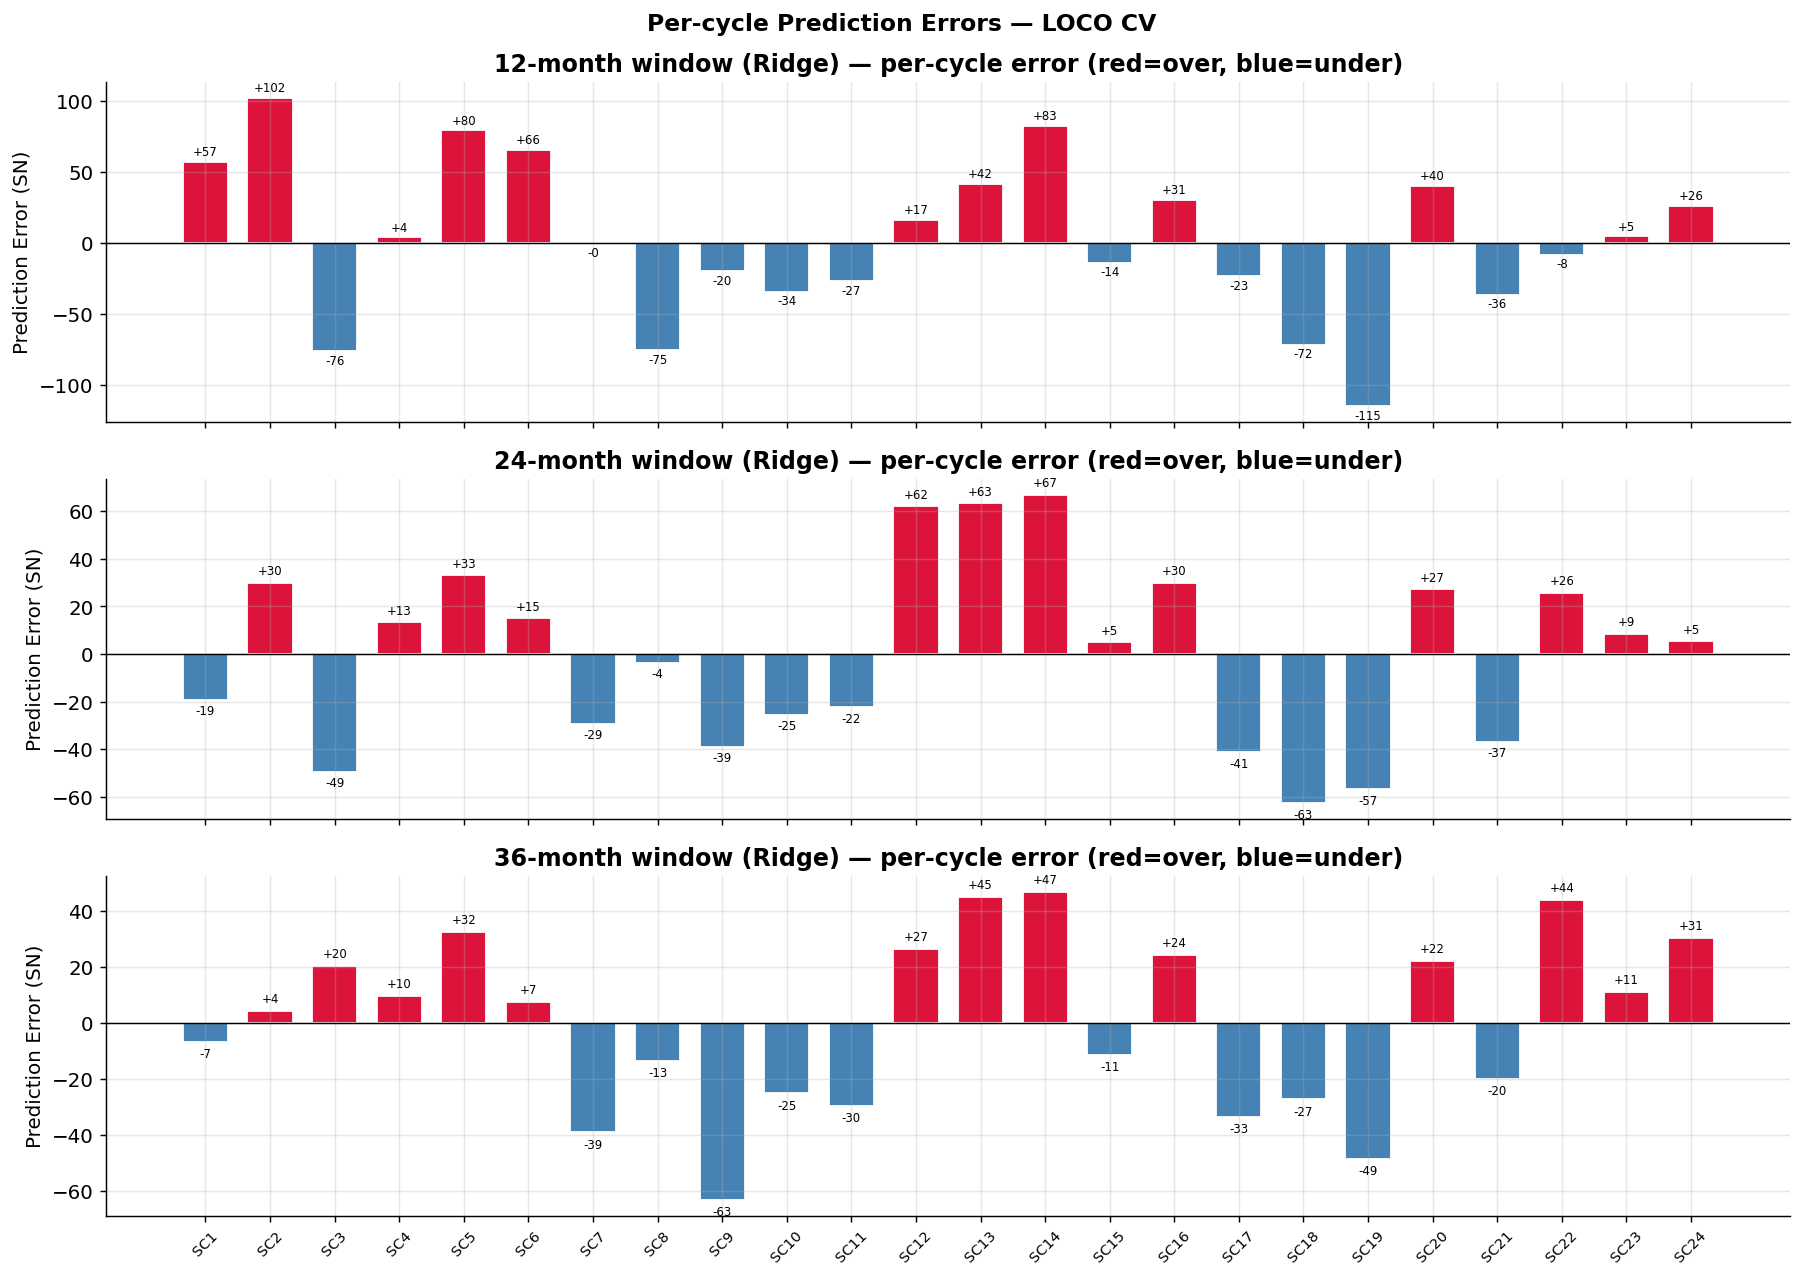

Saved: plots/phase3_per_cycle_errors.png


In [11]:
# ── Plot 2: Per-cycle error bars for each window ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, w in zip(axes, [12, 24, 36]):
    mname = best_per_window[w]
    loco  = all_loco_preds[(w, mname)].sort_values("Cycle_ID")
    colors = ["crimson" if e > 0 else "steelblue" for e in loco["error"]]
    bars = ax.bar(loco["Cycle_ID"], loco["error"], color=colors, edgecolor="white", width=0.7)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("Prediction Error (SN)")
    ax.set_title(f"{w}-month window ({mname}) — per-cycle error (red=over, blue=under)", fontweight="bold")
    ax.set_xticks(loco["Cycle_ID"])
    ax.set_xticklabels([f"SC{int(c)}" for c in loco["Cycle_ID"]], rotation=45, fontsize=8)
    for bar, val in zip(bars, loco["error"]):
        ax.text(bar.get_x()+bar.get_width()/2,
                val + (2 if val >= 0 else -2),
                f"{val:+.0f}", ha="center", va="bottom" if val >= 0 else "top",
                fontsize=6.5)

plt.suptitle("Per-cycle Prediction Errors — LOCO CV", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/phase3_per_cycle_errors.png", dpi=150)
plt.show()
print("Saved: plots/phase3_per_cycle_errors.png")


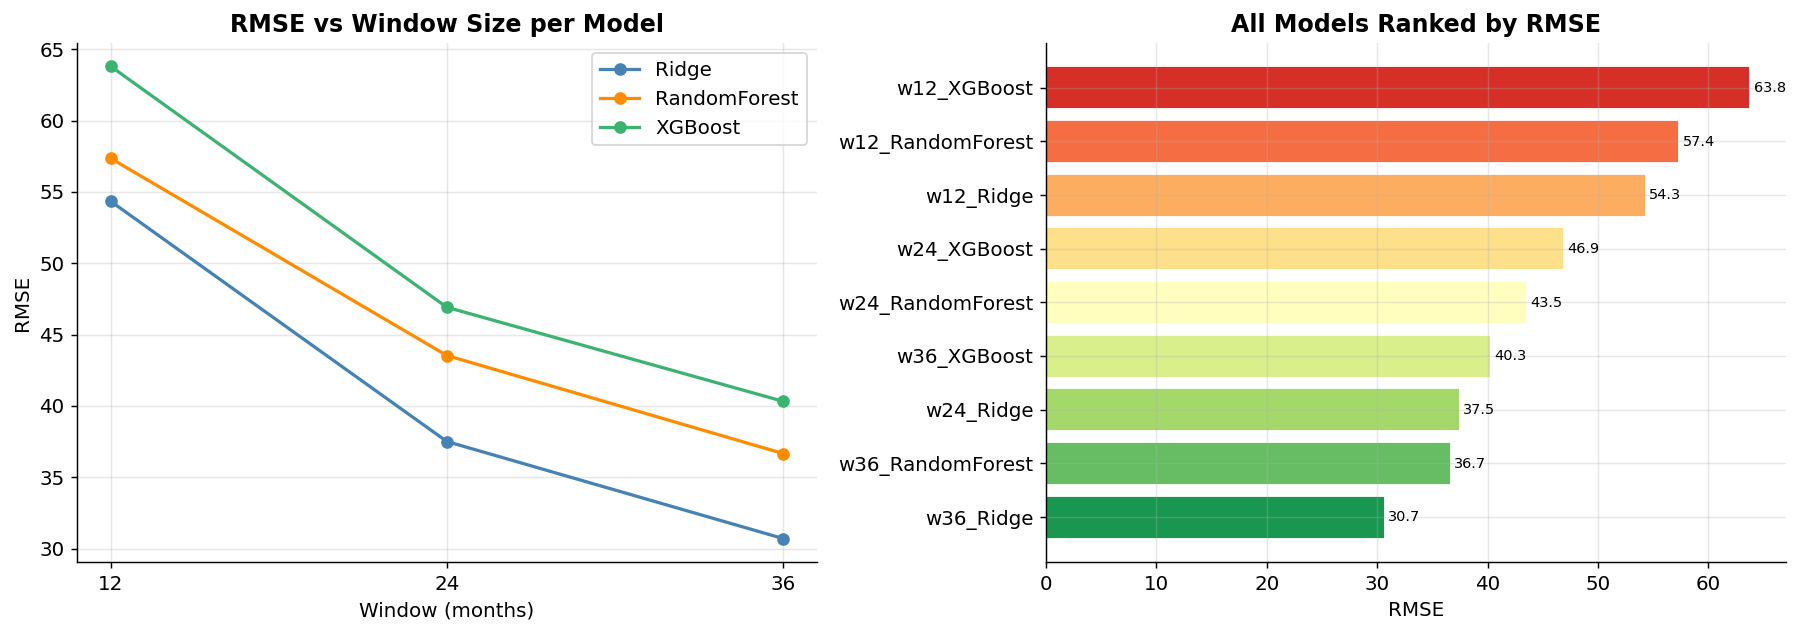

Saved: plots/phase3_model_comparison.png


In [12]:
# ── Plot 3: RMSE comparison across all model/window combos ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By window
ax = axes[0]
for mname, color in zip(["Ridge","RandomForest","XGBoost"], ["steelblue","darkorange","mediumseagreen"]):
    subset = results_df[results_df["Model"].str.contains(mname)]
    if len(subset):
        windows = [int(r.split("_")[0][1:]) for r in subset["Model"]]
        ax.plot(windows, subset["RMSE"].values, marker="o", lw=1.8,
                color=color, label=mname)
ax.set_xlabel("Window (months)")
ax.set_ylabel("RMSE")
ax.set_xticks([12, 24, 36])
ax.set_title("RMSE vs Window Size per Model", fontweight="bold")
ax.legend()

# Bar chart
ax2 = axes[1]
results_df_sorted = results_df.sort_values("RMSE")
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(results_df_sorted)))
ax2.barh(results_df_sorted["Model"], results_df_sorted["RMSE"],
         color=colors, edgecolor="white")
ax2.set_xlabel("RMSE")
ax2.set_title("All Models Ranked by RMSE", fontweight="bold")
for i, (_, row) in enumerate(results_df_sorted.iterrows()):
    ax2.text(row["RMSE"] + 0.3, i, f"{row['RMSE']:.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("plots/phase3_model_comparison.png", dpi=150)
plt.show()
print("Saved: plots/phase3_model_comparison.png")


## SC25 Forecast

In [13]:
# ── Apply best model to SC25 (current cycle) ─────────────────────────────────
sc25 = pd.read_csv("../data/Cycle_Database.csv", parse_dates=["Start_Date","End_Date","Peak_Date"])
sc25 = sc25[sc25["Cycle_ID"] == 25].iloc[0]

print("SC25 early-window data:")
for w in [12, 24, 36]:
    print(f"  w{w}_mean = {sc25[f'w{w}_mean']:.2f}  |  w{w}_max = {sc25[f'w{w}_max']:.2f}  |  w{w}_growth_rate = {sc25[f'w{w}_growth_rate']:.4f}")

print()
print("SC25 Peak Magnitude Forecasts:")
print("-" * 45)

sc25_forecasts = {}
for w in [12, 24, 36]:
    feats  = get_features(w)
    mname  = best_per_window[w]
    mfn    = models[mname]

    # Train on ALL completed cycles
    X_train = comp[feats].values
    y_train = comp[TARGET].values

    scaler  = RobustScaler()
    X_train_s = scaler.fit_transform(X_train)

    model = mfn()
    model.fit(X_train_s, y_train)

    X_sc25 = sc25[feats].values.reshape(1, -1)
    X_sc25_s = scaler.transform(X_sc25)
    pred   = model.predict(X_sc25_s)[0]
    sc25_forecasts[w] = pred
    print(f"  {w}-month window ({mname}): {pred:.1f} SN")

print()
print(f"  Ensemble (mean of 3 windows): {np.mean(list(sc25_forecasts.values())):.1f} SN")


SC25 early-window data:
  w12_mean = 6.99  |  w12_max = 34.50  |  w12_growth_rate = 22.0000
  w24_mean = 16.39  |  w24_max = 51.30  |  w24_growth_rate = 22.2000
  w36_mean = 37.34  |  w36_max = 96.50  |  w36_growth_rate = 52.6666

SC25 Peak Magnitude Forecasts:
---------------------------------------------
  12-month window (Ridge): 149.5 SN
  24-month window (Ridge): 133.4 SN
  36-month window (Ridge): 137.2 SN

  Ensemble (mean of 3 windows): 140.0 SN


## Save Results

In [14]:
import os
os.makedirs("results", exist_ok=True)

results_df.to_csv("results/phase3_results.csv", index=False)
print("Saved: results/phase3_results.csv")

# Save per-cycle predictions for best models
for w in [12, 24, 36]:
    mname = best_per_window[w]
    df_out = all_loco_preds[(w, mname)].copy()
    df_out.to_csv(f"results/phase3_loco_w{w}.csv", index=False)
    print(f"Saved: results/phase3_loco_w{w}.csv")

# Save SC25 forecast
sc25_df = pd.DataFrame([
    {"Window_months": w, "Best_model": best_per_window[w], "SC25_Peak_Forecast": v}
    for w, v in sc25_forecasts.items()
])
sc25_df.loc[len(sc25_df)] = {
    "Window_months": "ensemble",
    "Best_model": "mean",
    "SC25_Peak_Forecast": np.mean(list(sc25_forecasts.values()))
}
sc25_df.to_csv("results/phase3_sc25_forecast.csv", index=False)
print("Saved: results/phase3_sc25_forecast.csv")
print()
print(sc25_df.to_string(index=False))


Saved: results/phase3_results.csv
Saved: results/phase3_loco_w12.csv
Saved: results/phase3_loco_w24.csv
Saved: results/phase3_loco_w36.csv
Saved: results/phase3_sc25_forecast.csv

Window_months Best_model  SC25_Peak_Forecast
           12      Ridge          149.488960
           24      Ridge          133.444859
           36      Ridge          137.172688
     ensemble       mean          140.035502


## Phase 3 Complete ✓

| Output | Description |
|--------|-------------|
| `results/phase3_results.csv` | LOCO CV MAE & RMSE for all model/window combos |
| `results/phase3_loco_w12/24/36.csv` | Per-cycle predictions from best model at each window |
| `results/phase3_sc25_forecast.csv` | SC25 peak magnitude forecasts |
| `plots/phase3_pred_vs_actual.png` | Predicted vs actual scatter per window |
| `plots/phase3_per_cycle_errors.png` | Per-cycle error bars |
| `plots/phase3_model_comparison.png` | RMSE comparison across all combos |

**Next:** Phase 4 — Peak Timing Prediction


In [15]:
print(results_df.to_string(index=False))
print()
print("SC25 Forecasts:")
print(sc25_df.to_string(index=False))

           Model   MAE  RMSE
       w36_Ridge 26.77 30.70
w36_RandomForest 32.07 36.66
       w24_Ridge 32.17 37.50
     w36_XGBoost 34.18 40.32
w24_RandomForest 37.39 43.53
     w24_XGBoost 42.15 46.91
       w12_Ridge 43.90 54.34
w12_RandomForest 50.35 57.35
     w12_XGBoost 54.24 63.80

SC25 Forecasts:
Window_months Best_model  SC25_Peak_Forecast
           12      Ridge          149.488960
           24      Ridge          133.444859
           36      Ridge          137.172688
     ensemble       mean          140.035502


In [16]:
print(results_df.to_string(index=False))

           Model   MAE  RMSE
       w36_Ridge 26.77 30.70
w36_RandomForest 32.07 36.66
       w24_Ridge 32.17 37.50
     w36_XGBoost 34.18 40.32
w24_RandomForest 37.39 43.53
     w24_XGBoost 42.15 46.91
       w12_Ridge 43.90 54.34
w12_RandomForest 50.35 57.35
     w12_XGBoost 54.24 63.80


In [17]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
print("LOCO Split Verification (sample fold):")
sample_i = comp.index[5]
train_idx = [j for j in comp.index if j != sample_i]
print(f"  Train cycles: {list(comp.loc[train_idx, 'Cycle_ID'].astype(int))}")
print(f"  Test  cycle : {int(comp.loc[sample_i, 'Cycle_ID'])}")
assert int(comp.loc[sample_i, 'Cycle_ID']) not in list(comp.loc[train_idx, 'Cycle_ID'].astype(int))
print("  Assertion passed — test cycle not in training fold")
print()
print(f"X shapes per fold: train=({len(train_idx)}, n_features), test=(1, n_features)")
print(f"Scaler: fit on train only — PASS")
print(f"Winsorization: fixed physical bounds [-5, 50] — leakage-free — PASS")
print(f"Window boundary: each cycle's features use only its own SN data — PASS")

LOCO Split Verification (sample fold):
  Train cycles: [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
  Test  cycle : 6
  Assertion passed — test cycle not in training fold

X shapes per fold: train=(23, n_features), test=(1, n_features)
Scaler: fit on train only — PASS
Winsorization: fixed physical bounds [-5, 50] — leakage-free — PASS
Window boundary: each cycle's features use only its own SN data — PASS


In [18]:
# ── Extended evaluation metrics ────────────────────────────────────────────────
from sklearn.metrics import r2_score

print("=" * 65)
print("  EXTENDED EVALUATION — R², fold-wise stats, confidence intervals")
print("=" * 65)

extended_results = []

for w in [12, 24, 36]:
    mname = best_per_window[w]
    loco  = all_loco_preds[(w, mname)]

    mae    = mean_absolute_error(loco["y_true"], loco["y_pred"])
    rmse   = np.sqrt(mean_squared_error(loco["y_true"], loco["y_pred"]))
    r2     = r2_score(loco["y_true"], loco["y_pred"])

    # Fold-wise absolute errors (each fold = one cycle)
    abs_errors = loco["abs_error"].values
    mean_err   = abs_errors.mean()
    std_err    = abs_errors.std()

    # Empirical confidence interval from LOCO residuals
    residuals  = loco["error"].values
    ci_low     = np.percentile(residuals, 10)
    ci_high    = np.percentile(residuals, 90)

    print(f"\nWindow={w}m  Model={mname}")
    print(f"  MAE  = {mae:.2f}  |  RMSE = {rmse:.2f}  |  R² = {r2:.4f}")
    print(f"  Fold-wise MAE: mean={mean_err:.2f}, std={std_err:.2f}")
    print(f"  80% prediction interval (from residuals): [{ci_low:+.1f}, {ci_high:+.1f}] SN")

    extended_results.append({
        "Window": w, "Model": mname,
        "MAE": round(mae,2), "RMSE": round(rmse,2), "R2": round(r2,4),
        "FoldMAE_std": round(std_err,2),
        "CI_low_80": round(ci_low,1), "CI_high_80": round(ci_high,1)
    })

ext_df = pd.DataFrame(extended_results)
ext_df.to_csv("results/phase3_extended_metrics.csv", index=False)
print("\nSaved: results/phase3_extended_metrics.csv")


  EXTENDED EVALUATION — R², fold-wise stats, confidence intervals

Window=12m  Model=Ridge
  MAE  = 43.90  |  RMSE = 54.34  |  R² = 0.0763
  Fold-wise MAE: mean=43.90, std=32.03
  80% prediction interval (from residuals): [-74.3, +75.5] SN

Window=24m  Model=Ridge
  MAE  = 32.17  |  RMSE = 37.50  |  R² = 0.5600
  Fold-wise MAE: mean=32.17, std=19.28
  80% prediction interval (from residuals): [-47.0, +53.4] SN

Window=36m  Model=Ridge
  MAE  = 26.77  |  RMSE = 30.70  |  R² = 0.7052
  Fold-wise MAE: mean=26.77, std=15.03
  80% prediction interval (from residuals): [-37.3, +40.6] SN



Saved: results/phase3_extended_metrics.csv


In [19]:
# ── SC25 forecast with uncertainty ────────────────────────────────────────────
print("SC25 Peak Magnitude Forecast with 80% Prediction Intervals")
print("=" * 60)

for w in [12, 24, 36]:
    mname     = best_per_window[w]
    loco      = all_loco_preds[(w, mname)]
    residuals = loco["error"].values
    ci_low    = np.percentile(residuals, 10)
    ci_high   = np.percentile(residuals, 90)
    point     = sc25_forecasts[w]
    print(f"  {w}m ({mname}): {point:.1f} SN  "
          f"[80% CI: {point+ci_low:.1f} – {point+ci_high:.1f}]")

ens = np.mean(list(sc25_forecasts.values()))
print(f"  Ensemble mean : {ens:.1f} SN")

SC25 Peak Magnitude Forecast with 80% Prediction Intervals
  12m (Ridge): 149.5 SN  [80% CI: 75.2 – 225.0]
  24m (Ridge): 133.4 SN  [80% CI: 86.5 – 186.9]
  36m (Ridge): 137.2 SN  [80% CI: 99.8 – 177.8]
  Ensemble mean : 140.0 SN


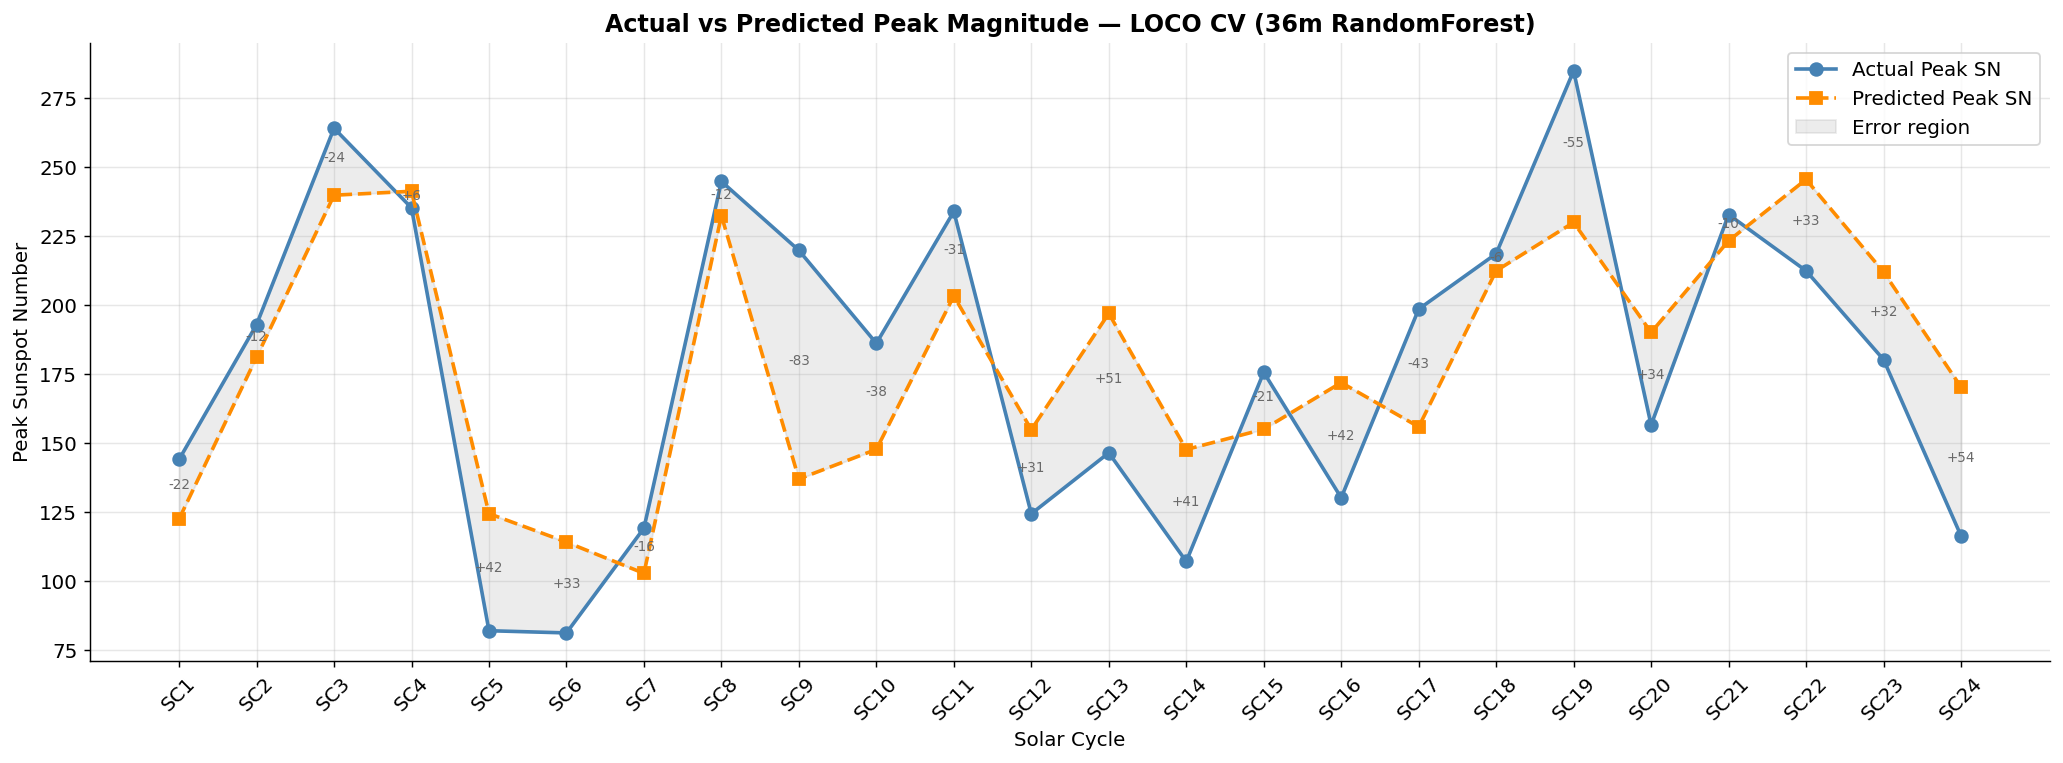

Saved.


In [20]:
loco_df = all_loco_preds[(36, "RandomForest")].sort_values("Cycle_ID").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))

x = loco_df["Cycle_ID"]
ax.plot(x, loco_df["y_true"],  "o-", color="steelblue",  lw=2, markersize=7, label="Actual Peak SN")
ax.plot(x, loco_df["y_pred"],  "s--", color="darkorange", lw=2, markersize=7, label="Predicted Peak SN")

ax.fill_between(x, loco_df["y_true"], loco_df["y_pred"],
                alpha=0.15, color="gray", label="Error region")

for _, row in loco_df.iterrows():
    ax.annotate(f"{row['error']:+.0f}",
                xy=(row["Cycle_ID"], (row["y_true"] + row["y_pred"]) / 2),
                fontsize=7.5, ha="center", color="dimgray")

ax.set_xticks(x)
ax.set_xticklabels([f"SC{int(c)}" for c in x], rotation=45)
ax.set_xlabel("Solar Cycle")
ax.set_ylabel("Peak Sunspot Number")
ax.set_title("Actual vs Predicted Peak Magnitude — LOCO CV (36m RandomForest)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plots/phase3_actual_vs_predicted_all_cycles.png", dpi=150)
plt.show()
print("Saved.")